In [1]:
#.............................................
# IMPORT STATEMENTS
#.............................................

# General package
import os

#Handling data
import numpy as np
import netCDF4 as nc

#machine learning package
import tensorflow as tf
from tensorflow import keras
from keras import layers

# Plotting figures
import matplotlib.pyplot as plt #Main plotting package
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
import cartopy.mpl.ticker as cticker

2026-03-01 16:05:10.407053: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
def get_gradients(inputs, model, top_pred_idx=None):
    """Computes the gradients of outputs w.r.t input image.

    Args:
        inputs: 2D/3D/4D matrix of samples
        top_pred_idx: (optional) Predicted label for the x_data
                      if classification problem. If regression,
                      do not include.

    Returns:
        Gradients of the predictions w.r.t img_input
    """
    # Cast the inputs as floats (still returns tensor)
    inputs = tf.cast(inputs, tf.float32)

    # Tracks grdaients of any trainable variables (can be modified by optimizer)
    with tf.GradientTape() as tape:
        # But this adds tracking to non-trainable tensors
        tape.watch(inputs)
        
        # Run the forward pass of the layer and record operations
        # on GradientTape.
        preds = model(inputs, training=False)  
        
        # For classification, grab the top class
        if top_pred_idx is not None:
            preds = preds[:, top_pred_idx]
        
    # Use the gradient tape to automatically retrieve
    # the gradients of the trainable variables with respect to the loss.        
    grads = tape.gradient(preds, inputs)
    return grads

def get_integrated_gradients(inputs, model, baseline=None, num_steps=50, top_pred_idx=None):
    """Computes Integrated Gradients for a prediction.

    Args:
        inputs (ndarray): 2D/3D/4D matrix of samples
        baseline (ndarray): The baseline image to start with for interpolation
        num_steps: Number of interpolation steps between the baseline
            and the input used in the computation of integrated gradients. These
            steps along determine the integral approximation error. By default,
            num_steps is set to 50.
        top_pred_idx: (optional) Predicted label for the x_data
                      if classification problem. If regression,
                      do not include.            

    Returns:
        Integrated gradients w.r.t input image
    """
    # If baseline is not provided, start with zeros
    # having same size as the input image.
    if baseline is None:
        input_size = np.shape(inputs)[1:]
        baseline = np.zeros(input_size).astype(np.float32)
    else:
        # Often a pure black image, but can vary
        # Here, generated by random_baseline_integrated_gradients function below
        # baseline = baseline.astype(np.float32) Returning EagerTensor object has no attribute 'astype', try this instead
        baseline = tf.cast(baseline, tf.float32)

    # 1. Do interpolation.
    # Generates steps along straight-line path from baseline to original input
    # inputs = inputs.astype(np.float32) Same error
    inputs = tf.cast(inputs, tf.float32)
    interpolated_inputs = [
        baseline + (step / num_steps) * (inputs - baseline)
        for step in range(num_steps + 1)
    ]
    interpolated_inputs = np.array(interpolated_inputs).astype(np.float32)

    # 3. Get the gradients
    grads = []
    for i, x_data in enumerate(interpolated_inputs):
        grad = get_gradients(x_data, model, top_pred_idx=top_pred_idx)     
        grads.append(grad)
    grads = tf.convert_to_tensor(grads, dtype=tf.float32)

    # 4. Approximate the integral using the trapezoidal rule
    # Averages gradient values at interval endpoints 
    # to estimate integral of all gradients
    grads = (grads[:-1] + grads[1:]) / 2.0
    avg_grads = tf.reduce_mean(grads, axis=0)
    # 5. Calculate integrated gradients and return
    integrated_grads = (inputs - baseline) * avg_grads
    return integrated_grads

def random_baseline_integrated_gradients(inputs, num_steps=50, num_runs=5, top_pred_idx=None):
    """Generates a number of random baseline images.

    Args:
        inputs (ndarray): 2D/3D/4D matrix of samples
        num_steps: Number of interpolation steps between the baseline
            and the input used in the computation of integrated gradients. These
            steps along determine the integral approximation error. By default,
            num_steps is set to 50.
        num_runs: number of baseline images to generate
        top_pred_idx: (optional) Predicted label for the x_data
                      if classification problem. If regression,
                      do not include.      

    Returns:
        Averaged integrated gradients for `num_runs` baseline images
    """
    # 1. List to keep track of Integrated Gradients (IG) for all the images
    integrated_grads = []

    # 2. Get the integrated gradients for all the baselines
    for run in range(num_runs):
        baseline = np.zeros(np.shape(inputs)[1:])
        for i in np.arange(0,np.shape(baseline)[0]):
            j = np.random.choice(np.arange(0,np.shape(inputs)[0]))
            baseline[i] = inputs[j,i]

        igrads = get_integrated_gradients(
            inputs=inputs,
            baseline=baseline,
            num_steps=num_steps,
            top_pred_idx=top_pred_idx)
        integrated_grads.append(igrads)

    # 3. Return the average integrated gradients for the image
    integrated_grads = tf.convert_to_tensor(integrated_grads)
    return tf.reduce_mean(integrated_grads, axis=0)



In [3]:
#.............................................
# GATHERING DATA (for implementation)
#.............................................

# Using data generated by get_cnn_data_v2 notebook
%run ./get_cnn_data_v2_cnk_copy.ipynb 

# change to specific directory for user running code 
os.chdir("/Users/Caroline/Desktop/school/MamalakisResearch") 
base_path = os.getcwd()

# everyone should have locally loaded 'data' folder
data_path = base_path + '/data/'

model_list = [
    "CNRM_ESM2-1_ssp119_ssp126_201501_210012_r1-5_2pt5degree.nc",
    "MIROC6_ssp119_ssp126_201501_210012_r1-5_2pt5degree.nc",
    "MPI-ESM1-2-LR_ssp119_ssp126_201501_210012_r1-5_2pt5degree.nc",
    "MRI-ESM2-0_ssp119_ssp126_201501_210012_r1-5_2pt5degree.nc",
    "UKESM1-0-LL_ssp119_ssp126_201501_210012_r1-5_2pt5degree.nc",
]


X_data, y_data = get_cnn_tensors( 
    model_list=model_list,
    scenario="ssp126",
    data_path=data_path,
    var_idx="all",
    use_anomaly=True,
    stat="mean",
    st_early=2015, end_early=2024,
    st_late=2055, end_late=2064
)

# split x and y data
X_train, Y_train, X_val, Y_val, X_test, Y_test = split_tensors(X_data, y_data)

Variable: ['tas', 'tasmax', 'tasmin', 'pr', 'psl', 'sfcWind', 'mrsos'] | Stat: mean | Anomaly: True
Processing Model: CNRM_ESM2-1


/var/folders/v4/nmf8gnpn5vb2t2vlt0df52mh0000gn/T/ipykernel_22715/2777151843.py:96: RuntimeWarning: Mean of empty slice
  v_mean = np.nanmean(v_data[:, b_start:b_end, :, :], axis=1)
/Users/Caroline/miniconda3/envs/climate/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/v4/nmf8gnpn5vb2t2vlt0df52mh0000gn/T/ipykernel_22715/2777151843.py:120: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=0)


Processing Model: MIROC6
Processing Model: MPI-ESM1-2-LR
Processing Model: MRI-ESM2-0
Processing Model: UKESM1-0-LL


2.15.0
Model: "cnk_cnn"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv_block (ConvBlock)      multiple                  41024     
                                                                 
 conv_block_1 (ConvBlock)    multiple                  27712     
                                                                 
 conv_block_2 (ConvBlock)    multiple                  6944      
                                                                 
 conv_block_3 (ConvBlock)    multiple                  1744      
                                                                 
 flatten (Flatten)           multiple                  0         
                                                                 
 dense (Dense)               multiple                  18050     
                                                                 
 dense_1 (Dense)             multiple               

/var/folders/v4/nmf8gnpn5vb2t2vlt0df52mh0000gn/T/ipykernel_22715/2777151843.py:96: RuntimeWarning: Mean of empty slice
  v_mean = np.nanmean(v_data[:, b_start:b_end, :, :], axis=1)
/var/folders/v4/nmf8gnpn5vb2t2vlt0df52mh0000gn/T/ipykernel_22715/2777151843.py:120: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=0)


Processing Model: MIROC6
Processing Model: MPI-ESM1-2-LR
Processing Model: MRI-ESM2-0
Processing Model: UKESM1-0-LL
Epoch 1/10
23/23 - 51s - loss: 3729136384.0000 - accuracy: 0.6350 - val_loss: 0.4220 - val_accuracy: 0.8000 - 51s/epoch - 2s/step
Epoch 2/10
23/23 - 32s - loss: 0.4686 - accuracy: 0.8275 - val_loss: 0.3535 - val_accuracy: 0.8600 - 32s/epoch - 1s/step
Epoch 3/10
23/23 - 27s - loss: 0.3149 - accuracy: 0.9050 - val_loss: 0.1631 - val_accuracy: 0.9800 - 27s/epoch - 1s/step
Epoch 4/10
23/23 - 31s - loss: 0.1350 - accuracy: 0.9725 - val_loss: 0.0597 - val_accuracy: 1.0000 - 31s/epoch - 1s/step
Epoch 5/10
23/23 - 29s - loss: 0.0558 - accuracy: 0.9900 - val_loss: 0.0339 - val_accuracy: 1.0000 - 29s/epoch - 1s/step
Epoch 6/10
23/23 - 30s - loss: 0.0307 - accuracy: 0.9975 - val_loss: 0.0235 - val_accuracy: 1.0000 - 30s/epoch - 1s/step
Epoch 7/10
23/23 - 29s - loss: 0.0374 - accuracy: 0.9925 - val_loss: 0.0141 - val_accuracy: 1.0000 - 29s/epoch - 1s/step
Epoch 8/10
23/23 - 25s - los

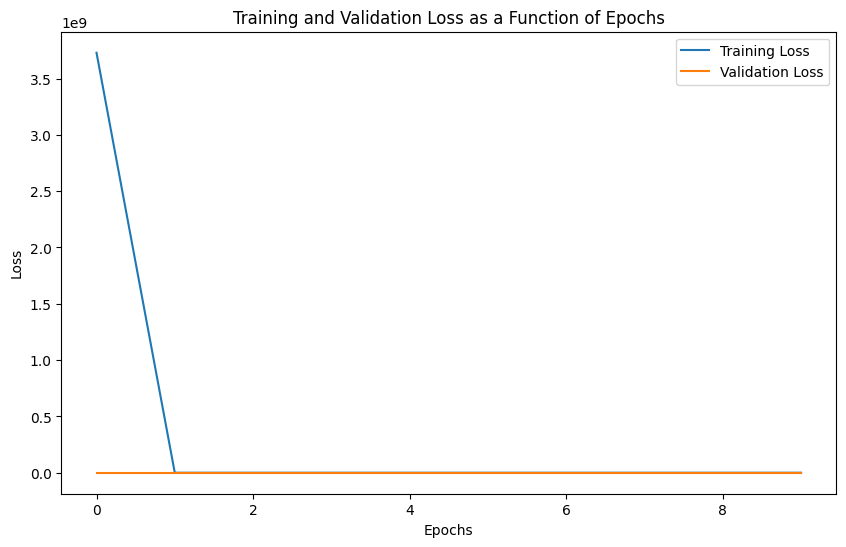

2/2 - 1s - loss: 0.0105 - accuracy: 1.0000 - 1s/epoch - 564ms/step
Test Loss: 0.010545825585722923
Test Accuracy: 1.0


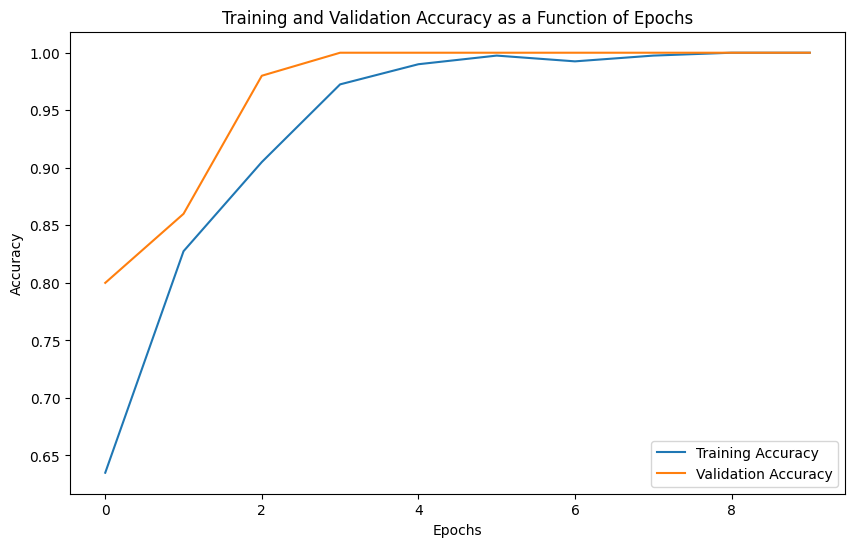

In [ ]:
# Run cnk_cnn_v0.ipynb
%run cnk_cnn_v0.ipynb

In [ ]:
# Call a model
model = CNK_CNN()

In [ ]:
#.............................................
# IMPLEMENTATION
#.............................................

IntegratedGrad_zeros_heatmap=get_integrated_gradients(X_test, model, baseline=np.mean(X_train), top_pred_idx=0).numpy()
IntegratedGrad_zeros_heatmap
# 50 sets of 144x73x7 arrays wrapped in a tuple
# 5 models x 5 ensembles per model
# So why 50?


In [59]:

# Avg all 50 ensembles PER VARIABLE --> start by aggregating each 144x73 ith array of 7 arrays with each other
avg_per_var = IntegratedGrad_zeros_heatmap.mean(axis=0)  # average across 50 --> (144, 73, 7)

# Each variable is a slice along the last axis
var_maps = []
for var in range(7):
    var_map = avg_per_var[:, :, var]  # (144, 73) map for variable i
    var_maps.append(var_map.T) # Each var_map is 144x73 --> flip so it's 73x144?



In [65]:
def plot_XAI(
    heatmap,
    file_path,
    title='Integrated Gradients' # Add functionality to be more descriptive later (var, time period, etc.)
):
    """
    Inputs:
    heat_map: an array produced through an Ingegrated Gradients process
    file_path: the file from which lat and lon are read; can be any of the map(s) used in prev funcs
    title: describes the plot, default is generic
    
    Returns:
    A 2D Cartesian projection with features highlighted according to importance as ranked by Integrated Gradients
    """
    # Load ds, lat, lon from file_path
    ds = nc.Dataset(file_path)
    lat = np.array(ds["lat"][:])
    lon = np.array(ds["lon"][:])
    
    field_cyc, lon_cyc = add_cyclic_point(heatmap, coord=lon) 
    cmap = "RdBu_r" # For transition between blue and red

    fig = plt.figure(figsize=(11, 4.5))
    ax = plt.axes(projection=ccrs.Robinson())
    ax.set_global()
    ax.coastlines(linewidth=0.8)

    mesh = ax.pcolormesh(
        lon_cyc, lat, field_cyc,
        transform=ccrs.PlateCarree(),
        shading="auto",
        vmin=float(np.nanmin(field_cyc)), vmax=float(np.nanmax(field_cyc)),
        cmap=cmap
    )

    cbar = plt.colorbar(mesh, ax=ax, orientation="vertical", pad=0.03, shrink=0.85)

    plt.title(title)
    plt.tight_layout()
    plt.show()


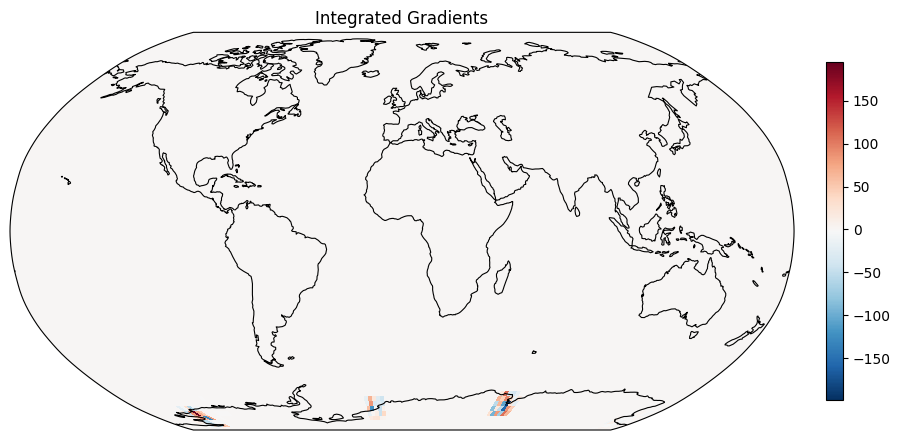

In [66]:
# Get lat and lon from opening any ds
file_path = data_path + '/CNRM_ESM2-1_ssp119_ssp126_201501_210012_r1-5_2pt5degree.nc'
ds = nc.Dataset(file_path)
lat = np.array(ds["lat"][:]) # extracting latitude and longitude grids
lon = np.array(ds["lon"][:])

# For tas
plot_XAI(var_maps[0], file_path)

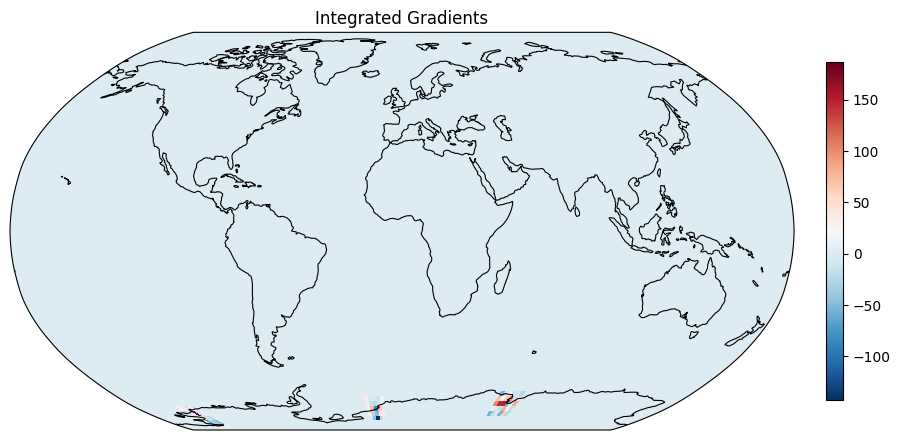

In [ ]:
# For tasmin
plot_XAI(var_maps[1], file_path)
# How to make symmetrical axes?